In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("IMDB Dataset.csv")

In [7]:
print(df.shape)
print(df.head())
print(df['sentiment'].value_counts())

(50000, 2)
                                              review sentiment
0  One of the other reviewers has mentioned that ...  positive
1  A wonderful little production. <br /><br />The...  positive
2  I thought this was a wonderful way to spend ti...  positive
3  Basically there's a family where a little boy ...  negative
4  Petter Mattei's "Love in the Time of Money" is...  positive
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


In [9]:
print(df.isnull().sum())
print(df.duplicated().sum())


review       0
sentiment    0
dtype: int64
418


In [14]:
print(df['review'][0])

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show is due to the fac

In [15]:
import re

def clean_text(text):
    text = re.sub(r'<.*?>', ' ', text)       
    text = re.sub(r'[^a-zA-Z\s]', '', text)  
    text = text.lower().strip()               
    return text

df['clean_review'] = df['review'].apply(clean_text)
print(df['clean_review'][0])

one of the other reviewers has mentioned that after watching just  oz episode youll be hooked they are right as this is exactly what happened with me  the first thing that struck me about oz was its brutality and unflinching scenes of violence which set in right from the word go trust me this is not a show for the faint hearted or timid this show pulls no punches with regards to drugs sex or violence its is hardcore in the classic use of the word  it is called oz as that is the nickname given to the oswald maximum security state penitentary it focuses mainly on emerald city an experimental section of the prison where all the cells have glass fronts and face inwards so privacy is not high on the agenda em city is home to manyaryans muslims gangstas latinos christians italians irish and moreso scuffles death stares dodgy dealings and shady agreements are never far away  i would say the main appeal of the show is due to the fact that it goes where other shows wouldnt dare forget pretty pi

In [17]:
df['label'] =  df['sentiment'].map({'positive':1,'negative':0}).astype('uint8')
print(df[['sentiment', 'label']].head())

  sentiment  label
0  positive      1
1  positive      1
2  positive      1
3  negative      0
4  positive      1


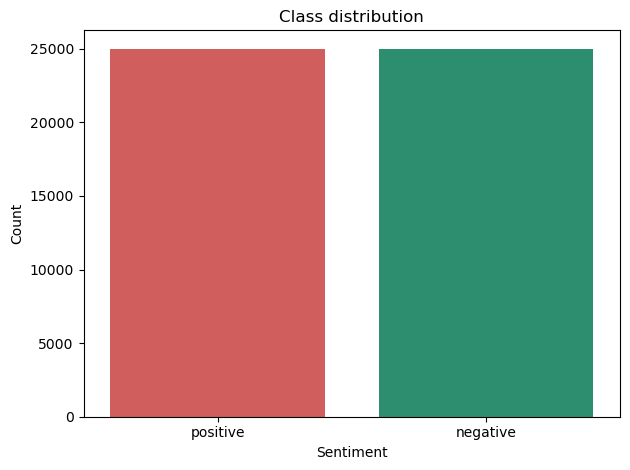

In [27]:

sns.countplot(x='sentiment', data=df, hue='sentiment', palette=['#E24B4A', '#1D9E75'], legend=False)
plt.title('Class distribution')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

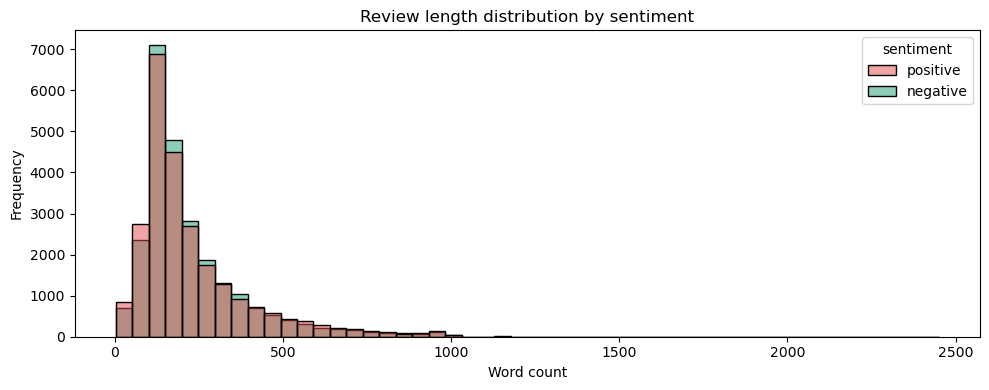

             count       mean         std   min    25%    50%    75%     max
sentiment                                                                   
negative   25000.0  224.97408  161.658851   4.0  125.0  171.0  273.0  1475.0
positive   25000.0  228.72644  174.431251  10.0  123.0  169.0  278.0  2450.0


In [28]:
df['review_length'] = df['clean_review'].apply(lambda x: len(x.split()))

plt.figure(figsize=(10, 4))
sns.histplot(data=df, x='review_length', hue='sentiment', bins=50, palette=['#E24B4A', '#1D9E75'])
plt.title('Review length distribution by sentiment')
plt.xlabel('Word count')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print(df.groupby('sentiment')['review_length'].describe())

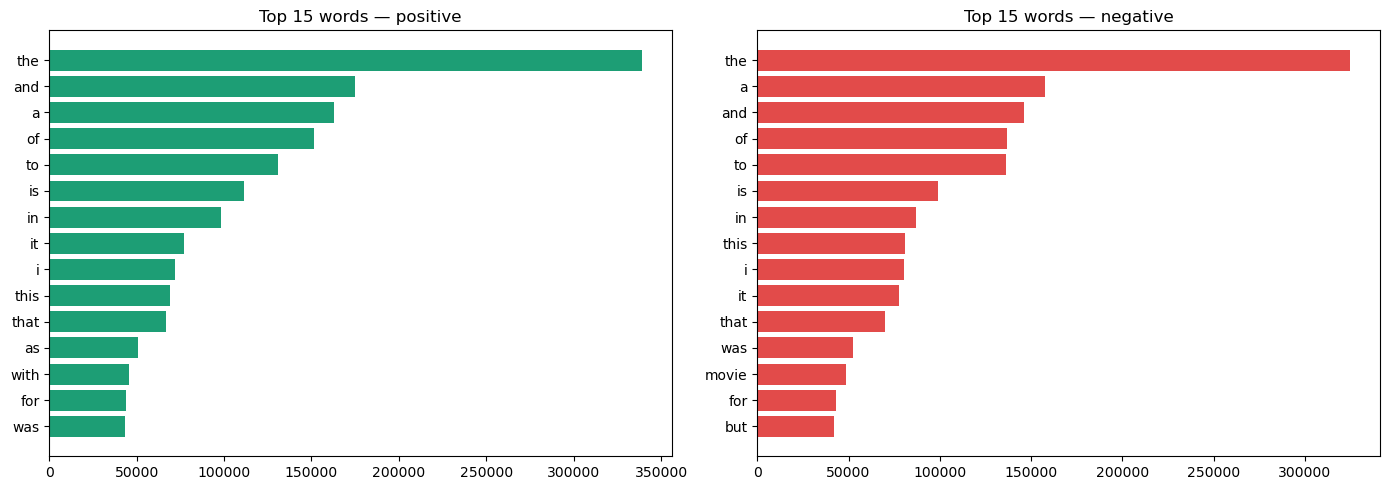

In [29]:
from collections import Counter

pos_words = ' '.join(df[df['sentiment'] == 'positive']['clean_review']).split()
neg_words = ' '.join(df[df['sentiment'] == 'negative']['clean_review']).split()

pos_top = Counter(pos_words).most_common(15)
neg_top = Counter(neg_words).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].barh([w for w, c in pos_top], [c for w, c in pos_top], color='#1D9E75')
axes[0].set_title('Top 15 words — positive')
axes[0].invert_yaxis()

axes[1].barh([w for w, c in neg_top], [c for w, c in neg_top], color='#E24B4A')
axes[1].set_title('Top 15 words — negative')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

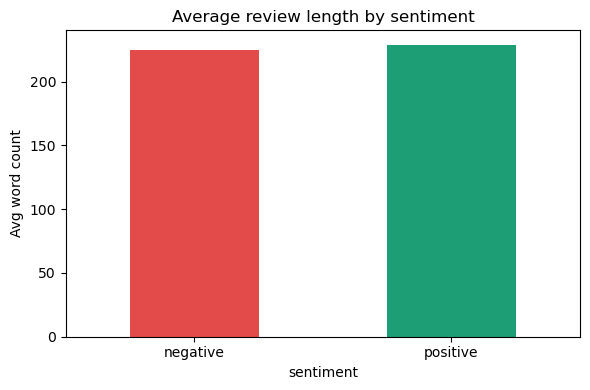

In [30]:
plt.figure(figsize=(6, 4))
df.groupby('sentiment')['review_length'].mean().plot(kind='bar', color=['#E24B4A', '#1D9E75'], edgecolor='none')
plt.title('Average review length by sentiment')
plt.ylabel('Avg word count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

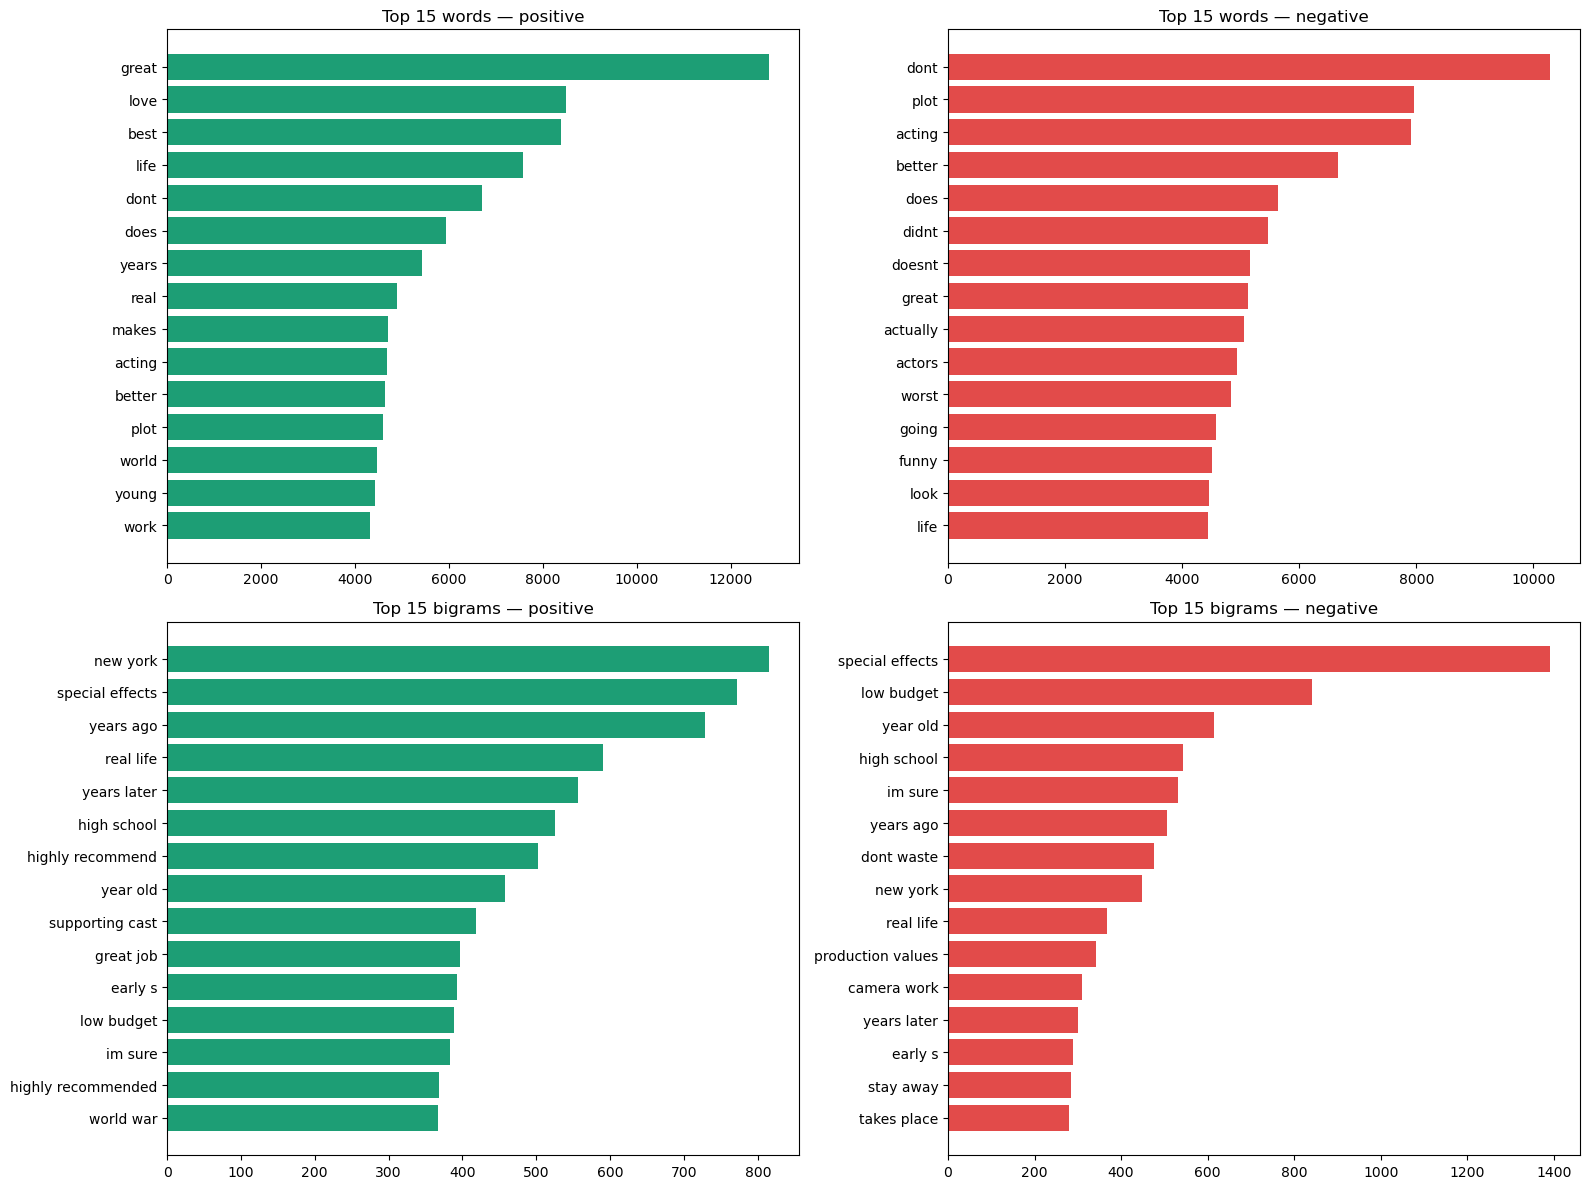

In [32]:
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

# expand stopwords with domain junk
custom_stopwords = set(ENGLISH_STOP_WORDS) | {
    'movie', 'film', 'movies', 'films', 'watch', 'watched',
    'watching', 'just', 'like', 'really', 'good', 'bad',
    'time', 'story', 'scene', 'scenes', 'character', 'characters',
    'make', 'made', 'way', 'think', 'know', 'seen', 'see',
    'lot', 'little', 'thing', 'things', 'people', 'man', 'woman'
}

def get_top_words(text_series, n=15):
    words = ' '.join(text_series).split()
    words = [w for w in words if w not in custom_stopwords and len(w) > 3]
    return Counter(words).most_common(n)

def get_top_bigrams(text_series, n=15):
    words = ' '.join(text_series).split()
    bigrams = [f"{words[i]} {words[i+1]}" for i in range(len(words)-1)]
    bigrams = [b for b in bigrams if not any(w in custom_stopwords for w in b.split())]
    return Counter(bigrams).most_common(n)

pos_reviews = df[df['sentiment'] == 'positive']['clean_review']
neg_reviews = df[df['sentiment'] == 'negative']['clean_review']

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# unigrams
pos_uni = get_top_words(pos_reviews)
neg_uni = get_top_words(neg_reviews)

axes[0][0].barh([w for w, c in pos_uni], [c for w, c in pos_uni], color='#1D9E75')
axes[0][0].set_title('Top 15 words — positive')
axes[0][0].invert_yaxis()

axes[0][1].barh([w for w, c in neg_uni], [c for w, c in neg_uni], color='#E24B4A')
axes[0][1].set_title('Top 15 words — negative')
axes[0][1].invert_yaxis()

# bigrams
pos_bi = get_top_bigrams(pos_reviews)
neg_bi = get_top_bigrams(neg_reviews)

axes[1][0].barh([w for w, c in pos_bi], [c for w, c in pos_bi], color='#1D9E75')
axes[1][0].set_title('Top 15 bigrams — positive')
axes[1][0].invert_yaxis()

axes[1][1].barh([w for w, c in neg_bi], [c for w, c in neg_bi], color='#E24B4A')
axes[1][1].set_title('Top 15 bigrams — negative')
axes[1][1].invert_yaxis()

plt.tight_layout()
plt.show()

In [33]:
from sklearn.model_selection import train_test_split

X = df['clean_review']
y = df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")
print(f"Train label dist:\n{y_train.value_counts()}")

Train size: 40000
Test size:  10000
Train label dist:
label
1    20000
0    20000
Name: count, dtype: int64


In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    stop_words='english'
)

X_train_tf = tfidf.fit_transform(X_train)
X_test_tf  = tfidf.transform(X_test)

print(f"Train matrix shape: {X_train_tf.shape}")
print(f"Test matrix shape:  {X_test_tf.shape}")

Train matrix shape: (40000, 50000)
Test matrix shape:  (10000, 50000)


In [53]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB(alpha=1.0)
model.fit(X_train_tf, y_train)


MultinomialNB()

In [50]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y_pred = model.predict(X_test_tf)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['negative', 'positive']))

Accuracy: 0.8780

              precision    recall  f1-score   support

    negative       0.88      0.87      0.88      5000
    positive       0.87      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



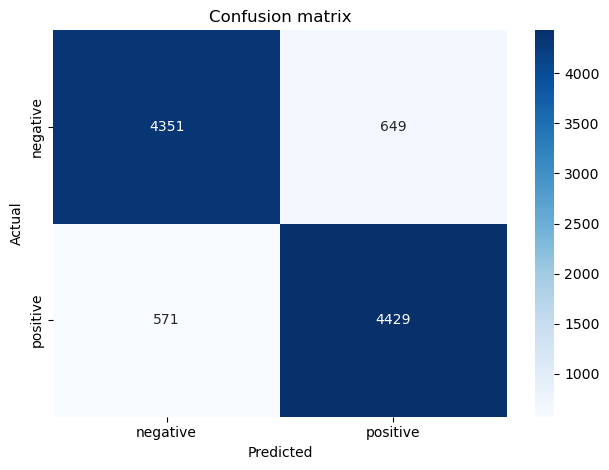

In [37]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title('Confusion matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [43]:
from sklearn.model_selection import cross_val_score

alphas = [0.1,0.2,0.5,1.0,2.0,5.0,10.0]
cv_scores = []

for alpha in alphas:
    nb = MultinomialNB(alpha = alpha)
    scores = cross_val_score(nb,X_train_tf,y_train,cv = 5,scoring='accuracy')
    cv_scores.append(scores.mean())
    print(f"alpha={alpha:<5} | cv accuracy={scores.mean():.4f} ± {scores.std():.4f}")


best_alpha = alphas[np.argmax(cv_scores)]
print(f"\nBest alpha: {best_alpha}")

alpha=0.1   | cv accuracy=0.8750 ± 0.0021
alpha=0.2   | cv accuracy=0.8749 ± 0.0017
alpha=0.5   | cv accuracy=0.8745 ± 0.0014
alpha=1.0   | cv accuracy=0.8735 ± 0.0018
alpha=2.0   | cv accuracy=0.8726 ± 0.0026
alpha=5.0   | cv accuracy=0.8702 ± 0.0024
alpha=10.0  | cv accuracy=0.8662 ± 0.0023

Best alpha: 0.1


In [54]:
best_model = MultinomialNB(alpha = 0.1)
best_model.fit(X_train_tf,y_train)

MultinomialNB(alpha=0.1)

Accuracy with best alpha: 0.8771
              precision    recall  f1-score   support

    negative       0.88      0.87      0.88      5000
    positive       0.87      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



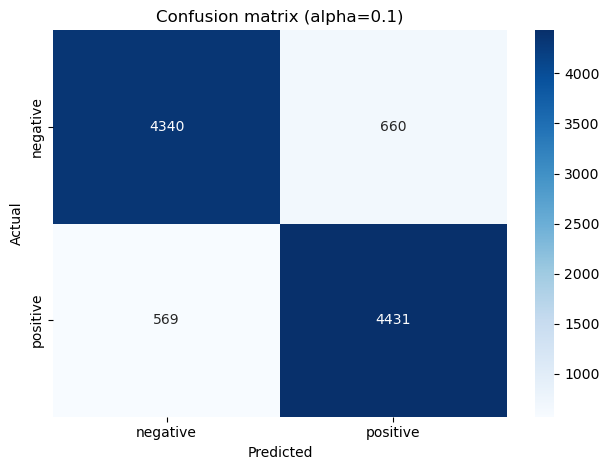

In [58]:
y_pred = best_model.predict(X_test_tf)
print(f"Accuracy with best alpha: {accuracy_score(y_test, y_pred):.4f}")

print(classification_report(y_test,y_pred, target_names=['negative', 'positive']))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['negative', 'positive'],
            yticklabels=['negative', 'positive'])
plt.title(f'Confusion matrix (alpha={best_alpha})')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [59]:
import pickle
import os

os.makedirs('artifacts', exist_ok=True)

with open('artifacts/model.pkl', 'wb') as f:
    pickle.dump(best_model, f)

with open('artifacts/tfidf.pkl', 'wb') as f:
    pickle.dump(tfidf, f)

print("Artifacts saved!")

Artifacts saved!


In [61]:
with open('artifacts/model.pkl', 'rb') as f:
    loaded_model = pickle.load(f)

with open('artifacts/tfidf.pkl', 'rb') as f:
    loaded_tfidf = pickle.load(f)

# quick sanity check
test_review = ["This movie was absolutely brilliant, loved every minute of it"]
vec = loaded_tfidf.transform(test_review)
pred = loaded_model.predict(vec)
prob = loaded_model.predict_proba(vec)

print(f"Prediction : {'positive' if pred[0] == 1 else 'negative'}")
print(f"Confidence : {prob[0].max():.4f}")

Prediction : positive
Confidence : 0.8550


In [62]:
import pkg_resources

packages = ['fastapi', 'uvicorn', 'scikit-learn', 'pandas', 'numpy']
for pkg in packages:
    try:
        version = pkg_resources.get_distribution(pkg).version
        print(f"{pkg}=={version}")
    except:
        print(f"{pkg} not found")

C:\Users\LOQ\AppData\Local\Temp\ipykernel_60052\254338610.py:1: DeprecationWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html
  import pkg_resources


fastapi not found
uvicorn not found
scikit-learn==1.6.1
pandas==2.2.3
numpy==2.1.3
